# EDA: Avito Auto parquet

Kernel: **diplom_avito**

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
ITEMS = ROOT / "items_with_attrs.parquet"
USERS = ROOT / "users_with_history.parquet"

items = pd.read_parquet(ITEMS)
users = pd.read_parquet(USERS)
users["contact_date"] = pd.to_datetime(users["contact_date"])

print("items", items.shape)
print("users", users.shape)

items (44736, 36)
users (2028, 9)


## 1. Items — схема и примеры

In [2]:
items.info()
items.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 44736 entries, 0 to 44735
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   serp_x                       44736 non-null  str    
 1   item_id                      44736 non-null  int64  
 2   block                        44736 non-null  str    
 3   block_pos                    44736 non-null  int32  
 4   price                        44736 non-null  float32
 5   image_count                  44736 non-null  float32
 6   item_cat_id                  44736 non-null  float32
 7   query_infm_logical_category  44736 non-null  str    
 8   query_loc                    44736 non-null  float32
 9   seller_is_private            44736 non-null  float32
 10  has_tc_events                44736 non-null  int32  
 11  has_x_events                 44736 non-null  int32  
 12  serp_is_positive             44736 non-null  bool   
 13  clicks_daily               

,serp_x,item_id,block,block_pos,price,image_count,item_cat_id,query_infm_logical_category,query_loc,seller_is_private,...,mileage_km,gearbox_text,fuel_text,body_type,drive_text,doors_text,year_text,rf_reg_text,imv,description_short
0,DIZLmBbYforhA7cZ,7822896198,extra-candidates-extra_regions,-1,1790000.0,14.0,9.0,Transport.UsedCars,654070.0,0.0,...,98000.0,автомат,бензин,седан,передний,4 дв,2016г (10 лет),учёт РФ,1756700.0,Максимальная комплектация!!! Вложений не требу...
1,O9itgHBPhPV4IOAV,8043564494,items,31,2519000.0,13.0,9.0,Transport.UsedCars,634450.0,0.0,...,90000.0,автомат,дизель,внедорожник,полный,5+ дв,2017г (9 лет),учёт РФ,2674200.0,«Вершина» - официальный дилер марки DongFeng и...
2,MKe3RXHoC9VQg11B,8127795498,extra-candidates-extra_regions,-1,550000.0,19.0,9.0,Transport.UsedCars,633540.0,0.0,...,350000.0,автомат,дизель,внедорожник,полный,5+ дв,2008г (18 лет),учёт РФ,840600.0,Продаю туарег с мотором 3.0 дизель Мотор в хор...
3,w3un0l42fDRGQZGF,8053164237,items,0,800000.0,20.0,9.0,Transport.UsedCars,652100.0,1.0,...,320000.0,вариатор,дизель,седан,передний,4 дв,2005г (21 год),учёт РФ,624800.0,"Машина ухожена, всё меняется вовремя!!!! Машин..."
4,RjPJOIp2eP4sm6Xt,8173485237,extra-candidates-extra_regions,-1,320000.0,5.0,9.0,Transport.UsedCars,645660.0,1.0,...,230000.0,механика,бензин,хэтчбек,передний,5+ дв,2008г (18 лет),учёт РФ,NaN,"Продам под восстановление, авто на ходу, завод..."
5,U6EyuAXtCWdeAGCb,8119704991,items,25,180000.0,3.0,9.0,Transport.UsedCars,634450.0,1.0,...,110000.0,механика,бензин,седан,задний,4 дв,2011г (15 лет),учёт РФ,209400.0,Машина в хорошем состоянии . Требуется ремонт ...
6,Ut6gsgGWSoGAe99S,7976805556,items,0,3990000.0,17.0,9.0,Transport.UsedCars,654070.0,0.0,...,28817.0,автомат,бензин,внедорожник,полный,5+ дв,2022г (4 года),учёт РФ,3817600.0,Представляем вашему вниманию автомобиль Mazda ...
7,sWwIj052EtZgID52,8058146556,extra-reg,14,2500000.0,11.0,9.0,Transport.UsedCars,107620.0,1.0,...,110000.0,автомат,бензин,внедорожник,полный,5+ дв,2019г (7 лет),учёт РФ,2836200.0,"За время владения проблем не было, Менялись то..."
8,a1WZrOv4TqRhtIuB,7971968830,items,26,580000.0,18.0,9.0,Transport.UsedCars,631870.0,1.0,...,41000.0,механика,бензин,седан,передний,4 дв,2019г (7 лет),учёт РФ,760000.0,"Я 1 хозяин, покупал в салоне. Не бита не краше..."
9,YSmSdG09ttHQdnG7,7968044639,items,2,1350000.0,9.0,9.0,Transport.UsedCars,630750.0,1.0,...,350000.0,автомат,дизель,внедорожник,полный,5+ дв,2009г (17 лет),учёт РФ,1348400.0,"Состояние хорошее, салон аккуратный, не работа..."


In [3]:
display(items[["serp_x", "item_id", "block", "block_pos", "price", "brand", "model_name", "title"]].sample(8, random_state=42))

,serp_x,item_id,block,block_pos,price,brand,model_name,title
34799,FdRVDwDzXugDf6uh,8109852801,extra-reg,7,1369000.0,SEAT,Leon,"SEAT Leon, С пробегом"
35615,xbVh7NEcQ3epXbH0,7677950206,items,11,6700000.0,BMW,3 серия,"BMW 3 серия, Новые"
10927,q2jppJ4nVxlmS6m1,8048160885,items,22,1080000.0,Porsche,Cayenne Turbo,"Porsche Cayenne Turbo, С пробегом"
28436,LRRDevDa8wk4HueB,8022511707,items,17,800000.0,Ford,Focus,"Ford Focus, С пробегом"
6978,7O93SPxlsHywtWOU,7824508099,extra-candidates-extra_regions,-1,1000.0,Audi,A4,"Audi A4, С пробегом"
9118,7vrfFFLzHd1B2buB,7986266504,extra-reg,5,2100000.0,Chrysler,300C,"Chrysler 300C, С пробегом"
18532,RHuC2tZbDb0Fz20H,7948770321,extra-candidates-extra_regions,-1,588000.0,Honda,Civic,"Honda Civic, С пробегом"
29279,ENhV8kjJJyYgyrtS,7975720119,extra-reg,16,600000.0,Lexus,RX,"Lexus RX, С пробегом"


In [4]:
cols = ["price", "block_pos", "clicks_daily", "contacts_daily", "desc_len"]
items[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,44736.0,1.399573e+06,2.374617e+06,10.0,345000.000000,770000.000000,1.600000e+06,8.000000e+07
block_pos,44736.0,1.197476e+01,1.153013e+01,-1.0,1.000000,10.000000,2.100000e+01,4.900000e+01
clicks_daily,44736.0,1.222355e+02,3.672659e+02,0.0,12.477721,33.293158,9.289457e+01,1.735290e+04
contacts_daily,44736.0,1.686123e+00,8.389912e+00,0.0,0.088827,0.289102,9.205480e-01,9.482315e+02
desc_len,44736.0,1.077168e+02,1.252798e+02,0.0,27.000000,62.000000,1.400000e+02,1.141000e+03


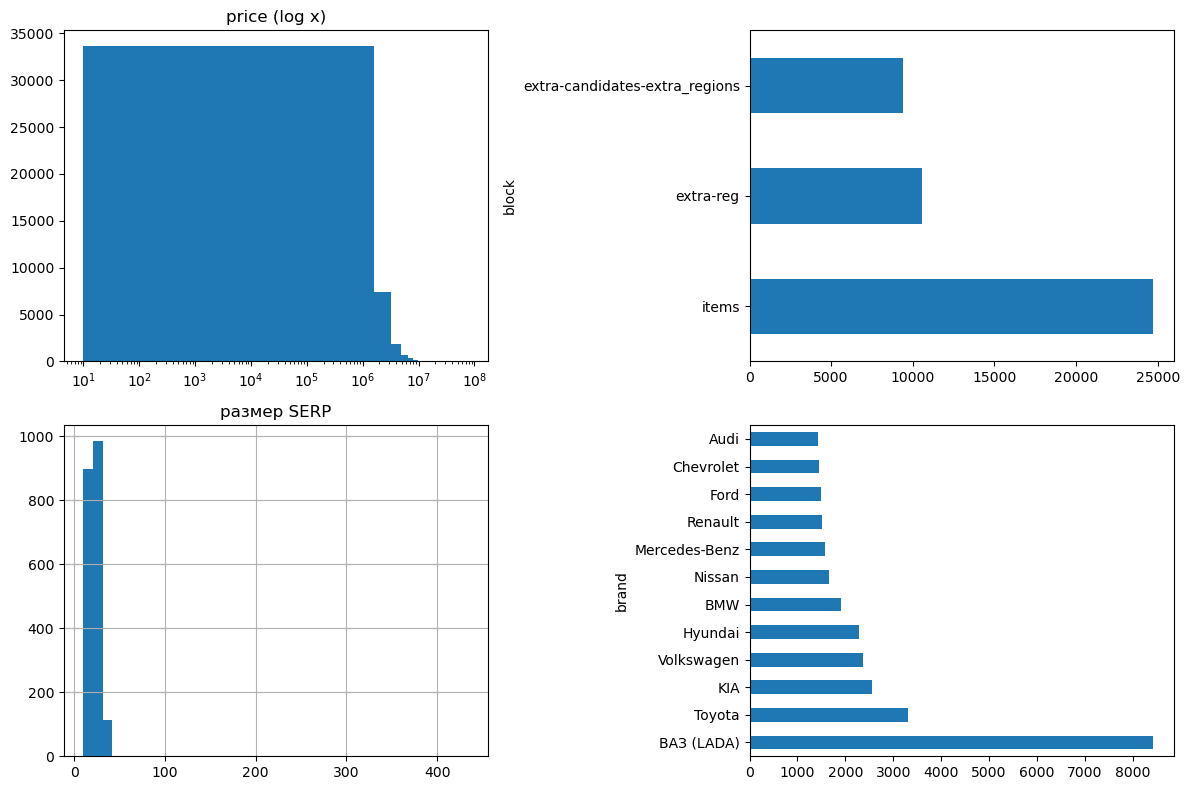

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
items["price"].replace(0, pd.NA).dropna().pipe(lambda s: axes[0,0].hist(s, bins=50))
axes[0,0].set_xscale("log"); axes[0,0].set_title("price (log x)")
items["block"].value_counts().plot(kind="barh", ax=axes[0,1])
items.groupby("serp_x").size().hist(bins=40, ax=axes[1,0])
axes[1,0].set_title("размер SERP")
items["brand"].value_counts().head(12).plot(kind="barh", ax=axes[1,1])
plt.tight_layout()

## 2. Users — история контактов

In [8]:
users.info()
users.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 2028 entries, 0 to 2027
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   user_id       2028 non-null   int64        
 1   item_id       2028 non-null   int64        
 2   contact_date  2028 non-null   datetime64[s]
 3   brand         1003 non-null   str          
 4   model_name    274 non-null    str          
 5   year_raw      0 non-null      object       
 6   mileage_km    0 non-null      object       
 7   gearbox_text  2028 non-null   str          
 8   fuel_text     2028 non-null   str          
dtypes: datetime64[s](1), int64(2), object(2), str(4)
memory usage: 184.8+ KB


,user_id,item_id,contact_date,brand,model_name,year_raw,mileage_km,gearbox_text,fuel_text
0,385580176,7939127023,2026-03-05,Наручные или карманные,NaN,None,None,,
1,310872417,8105074940,2026-05-12,NaN,NaN,None,None,,
2,188682502,7552041741,2026-05-20,NaN,NaN,None,None,,
3,137593361,8065383764,2026-03-30,NaN,NaN,None,None,,
4,408479957,7384293349,2026-04-19,NaN,NaN,None,None,,
5,175194920,7645630875,2026-03-20,Другие тягачи,NaN,None,None,,
6,101665397,8140917185,2026-05-02,Смарт-часы или браслет,NaN,None,None,,
7,188682502,8045708799,2026-03-05,NaN,NaN,None,None,,
8,13619259,7848760550,2026-03-16,NaN,NaN,None,None,,
9,432932462,4695542129,2026-05-07,NaN,NaN,None,None,,


In [9]:
users.groupby("user_id").size().describe()

count    274.000000
mean       7.401460
std       17.316895
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      178.000000
dtype: float64

Text(0, 0.5, 'событий')

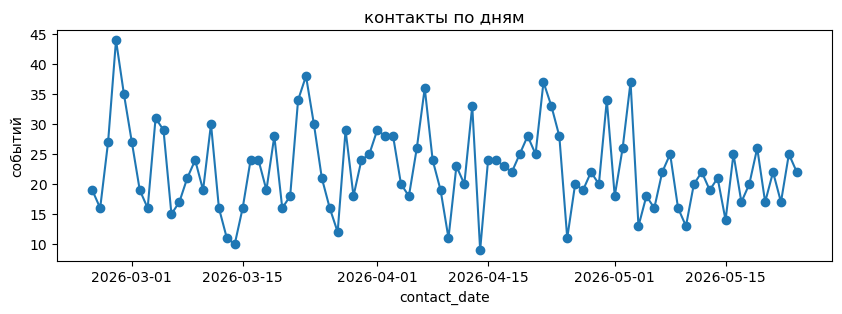

In [10]:
users.groupby(users["contact_date"].dt.date).size().plot(figsize=(10, 3), marker="o")
plt.title("контакты по дням"); plt.ylabel("событий")

## 3. Связь таблиц

In [11]:
u_items = set(items["user_id"].dropna().astype(int))
u_hist = set(users["user_id"])
i_hist = set(users["item_id"])
i_items = set(items["item_id"])
print("users in both tables:", len(u_hist & u_items), "/", len(u_hist))
print("item_id overlap:", len(i_hist & i_items), "(0 = разные срезы)")

users in both tables: 274 / 274
item_id overlap: 0 (0 = разные срезы)


In [12]:
# пример: все показы SERP для пользователя из истории
uid = users["user_id"].iloc[0]
sub = items[items["user_id"] == uid]
print("user_id", uid, "rows in items as seller:", len(sub))
hist = users[users["user_id"] == uid]
display(hist)
display(sub.head(5)[["serp_x", "title", "price", "block_pos"]])

user_id 385580176 rows in items as seller: 20


,user_id,item_id,contact_date,brand,model_name,year_raw,mileage_km,gearbox_text,fuel_text
0,385580176,7939127023,2026-03-05,Наручные или карманные,NaN,None,None,,
67,385580176,8006595577,2026-05-09,NaN,NaN,None,None,,
124,385580176,7998137155,2026-05-10,NaN,NaN,None,None,,
457,385580176,8037311289,2026-04-13,NaN,NaN,None,None,,
458,385580176,8037311289,2026-04-19,NaN,NaN,None,None,,
1658,385580176,7947684956,2026-04-17,NaN,NaN,None,None,,
1740,385580176,7602154994,2026-03-26,Смарт-часы или браслет,NaN,None,None,,
1741,385580176,7602154994,2026-03-29,Смарт-часы или браслет,NaN,None,None,,
1994,385580176,7959025545,2026-03-01,Смарт-часы или браслет,NaN,None,None,,


,serp_x,title,price,block_pos
1157,jhKf9jA3s9oc7e5U,"ГАЗ ГАЗель 3302, Новые",2637000.0,25
2819,jhKf9jA3s9oc7e5U,"ГАЗ ГАЗель 3302, С пробегом",730000.0,23
3436,jhKf9jA3s9oc7e5U,"ГАЗ ГАЗель 3302, Новые",2599000.0,6
4743,jhKf9jA3s9oc7e5U,"ГАЗ ГАЗель 3302, С пробегом",580000.0,3
7179,jhKf9jA3s9oc7e5U,"ГАЗ ГАЗель 3302, Новые",2882800.0,11


## 4. Тексты объявлений

In [13]:
for _, row in items.sample(3, random_state=1).iterrows():
    print("-" * 60)
    print(row["title"], "|", row["price"], "₽")
    print(row["description_short"][:400])

------------------------------------------------------------
Chevrolet Cruze, С пробегом | 685000.0 ₽
Всем доброго дня! В продаже Chevrolet Cruze 2012 года выпуска в хорошем состоянии! У автомобиля за весь период эксплуатации(14 лет) было 4 собственника,родной подтвержденный пробег 166 тыс километров,было два мелких ДТП,притёртости во дворе(наезд на…
------------------------------------------------------------
Nissan Almera Classic, С пробегом | 290000.0 ₽
Являюсь владельцем авто с 2013 года. Езжу каждый день. Пробег не смотан. Хим чистка салона не сделана, есть существенные недостатки по кузову, не работает ручной тормоз, лопнул трос открывания багажника. Во всём остальном никаких нареканий. Продаю т.
------------------------------------------------------------
Audi S8, С пробегом | 11690000.0 ₽
Сдержанный внешний вид и богатый коричневый салон. Именно так выглядит настоящая роскошь Audi Когда скорость скрыта за классикой. 571 л.с. делают своё дело незаметно Автомобиль с пробегом 63 3